# Ансамблевые алгоритмы машинного обучения

集成机器学习算法

# Качество простых алгоритмов

Простые алгоритмы, которые мы изучали раньше, зачастую дают не очень хороший прогноз предсказаний. Попробуем применить простые алгоритмы для решения одной из известных задач.

简单算法的质量

我们之前研究的简单算法通常不能产生很好的预测。让我们尝试应用简单的算法来解决已知问题之一。

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# 预处理逻辑回归的数据
from sklearn.preprocessing import StandardScaler

X, y = load_breast_cancer(return_X_y=True)

X_scaled = StandardScaler().fit_transform(X) # 正确的

X_train, x_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, shuffle=True, random_state=1917
)


In [ ]:
tree_clf = DecisionTreeClassifier().fit(X_train, y_train)
knn_clf = KNeighborsClassifier().fit(X_train, y_train)
linear_clf = LogisticRegression().fit(X_train, y_train)

In [ ]:
predictions_tree = tree_clf.predict(x_test)
predictions_knn = knn_clf.predict(x_test)
predictions_linear = linear_clf.predict(x_test)

In [ ]:
accuracy_tree = accuracy_score(predictions_tree, y_test)
accuracy_knn = accuracy_score(predictions_knn, y_test)
accuracy_linear = accuracy_score(predictions_linear, y_test)

In [ ]:
print(f'Accuracy of tree classifier: {accuracy_tree}\nAccuracy of knn classifier: {accuracy_knn}\nAccuracy of linear classifier: {accuracy_linear}')

Accuracy of tree classifier: 0.935672514619883
Accuracy of knn classifier: 0.9824561403508771
Accuracy of linear classifier: 0.9824561403508771


In [ ]:
(predictions_linear == predictions_knn).all()

np.False_

Каждый из этих классификаторов неплохо классифицирует исходный датасет. А что, если провести голосование?

每个分类器都能很好地对原始数据集进行分类。如果我们进行投票会怎么样？

In [ ]:
sum_of_voices = (
    predictions_tree.astype(int)
    + predictions_knn.astype(int)
    + predictions_linear.astype(int)
)
voiting_result = (sum_of_voices > 1).astype(int)

In [ ]:
accuracy_voiting = accuracy_score(voiting_result, y_test)
print(f"Voiting result: {accuracy_voiting}")

Voiting result: 1.0


Мы получили идеальное предсказание, объединив независимые мнения трёх различных классификаторов!

Да здравствует демократия!

**Такой подход называется ансамблированием.**

通过结合三个不同分类器的独立意见，我们得到了完美的预测！

民主万岁！

**这种方法称为集成。**

# Ансамбли

Ансамбли — серьёзные модели машинного обучения. Они мощные, и позволяют отражать сложные зависимости между данными. Однако, за «силу» ансамблей приходится платить их интерпретируемостью. Такие алгоритмы часто называют «чёрными ящиками»: по ним трудно понять, какие же признаки повлияли на прогноз для конкретного наблюдения. Вам решать, чем именно вы готовы пожертвовать, решая задачу.

Идея ансамбля моделей проста. Пусть вы решили задачу бинарной классификации моделью  $m_1$  на основе дерева принятия решений. Получили значение метрики accuracy = 0.8. Однако все модели склонны переобучаться. Один алгоритм, обученный на всех наблюдениях train и всех признаках, может сильно ошибаться на валидации. Есть идея взять ещё одну модель —  $m_2$ , компенсирующую ошибки первой. Сама по себе она также может давать не очень высокий accuracy. Например, accuracy=0.79. Можно поменять условия ещё раз и построить ещё одну модель  $m_3$, и так далее до модели  $m_n$. В итоге каждая модель из $n$ будет подвержена разным случайным факторам в зависимости от своих отличий, но при этом принесёт собственное сакральное знание о наблюдениях. Можно попытаться учесть их все одновременно — получить сводную модель $M$, которая будет давать результат лучше, чем каждая в отдельности, скажем, accuracy = 0.91. Такую сводную модель будем называть **сильной** (говорят «сильным классификатором»), а модели, на основании которых она построена — **слабыми** (или «слабыми классификаторами»).

集成

集成是严肃的机器学习模型。它们功能强大，可以让您反映数据之间的复杂依赖关系。然而，集成的“力量”是以牺牲可解释性为代价的。这种算法通常被称为“黑匣子”：很难理解哪些特征影响了特定观测的预测。为了解决这个问题你到底愿意牺牲什么取决于你自己。

模型集成的想法很简单。假设您使用基于决策树的模型 $m_1$ 解决了二元分类问题。我们得到了准确度指标的值 = 0.8。然而，所有模型都容易过度拟合。一种针对所有训练观测和所有特征进行训练的算法可能会在验证中犯下重大错误。有一个想法是采用另一个模型 - $m_2$，以弥补第一个模型的错误。就其本身而言，它可能也无法提供非常高的准确性。例如，准确度=0.79。你可以再次改变条件，构建另一个模型$m_3$，依此类推，直到模型$m_n$。因此，$n$个模型中的每一个模型都会根据其差异而受到不同的随机因素的影响，但同时也会带来自己关于观测的神圣知识。您可以尝试同时将它们全部考虑在内 - 获得一个组合模型 $M$，它将比单独考虑每个模型给出更好的结果，比如准确度 = 0.91。我们将这样的总结模型称为**强**（他们说“强分类器”），而将其所基于的模型称为**弱**（或“弱分类器”）。

# Разложение ошибки*

Вспомним постановку задачи регрессии (аналогичные рассуждения справедливы и для классификации). Пусть есть некоторая функция $f(x)$ и нормальный шум $ϵ$, причем мы будем считать, что $ϵ$ ~ $N(0, σ^2)$. Тогда в рамках постановки задачи регрессии мы имеем набор объектов $x_i \in X$ и соответствующий им набор меток:

$$y_i = f(x_i) + ϵ$$

Пусть мы также имеем некоторую функцию $\hat{f}(x)$ - наш вариант модели регрессии. Мы вводили понятие *эмпирического риска* $Q = E_X[L(x, y)]$

Часто в задачах мы используем среднеквадратическое отклонение в качестве $Q$:
$$Q = \frac{1}{N}\sum\limits_{i=1}^N (y_i - \hat{f}(x_i))^2$$
Попробуем оценить математическое ожидание* величины квадрата отклонения предсказания от метки:

$E[(y - \hat{f}(x))^2] = E[y^2] - 2y\hat{f}(x) + (\hat{f}(x))^2] = E[y^2] + E[(\hat{f}(x))^2] - 2E[y\hat{f}(x)] = $

//С этого момента будем опускать аргумент $(x)$ в записи $\hat{f}(x)$ ради упрощения восприятия текста//

$= E[y^2] + E[\hat{f}^2] - 2E[y\hat{f}] = $

Вспомним, что дисперсию $Dy$ можно определить, как $Dy = E[y^2] - (E[y])^2$(1)


$= Dy + (E[y])^2 + D\hat{f} + (E[\hat{f}])^2 - 2fE[\hat{f}] =$

Последний переход получился при помощи применения равенства (1) к предыдущему результату, а также вынесением $f$ за знак математического ожидания в последнем слагаемом в силу того, что  $y = f + ϵ$, где $f$ - детерменированная величина, а значит может быть вынесена за знак математического ожидания, а $ϵ$ имеет нулевое матожидание. Теперь вспомним, что $y = f + ϵ$, а значит $E[y] = E[f] + E[ϵ] = E[f]$

$= Dy + D\hat{f} + (E[f]^2 + E[\hat{f}]^2 - 2fE[\hat{f}]) = Dy + D\hat{f} + (f - E[\hat{f}])^2 = σ^2 + D\hat{f} + (f - E[\hat{f}])^2$

Последний переход получился, так как $Dy = D[f + ϵ]$, где $f$ - детерменированная величина, не вносящая вклада в дисперсию. Значит, $Dy = Dϵ = σ^2$

Итак, мы получили:

$$E[(y - \hat{f}(x))^2] = σ^2 + D\hat{f} + (f - E[\hat{f}])^2$$

То есть матожидание ошибки предсказания модели раскладывается в 3 слагаемых:

* $σ^2$ - дисперсия шума в исходных данных. Чем выше дисперсия шума, тем хуже предсказательная способность модели, то есть выше матожидание её ошибки. Это происходит из-за того, что сильный шум не даёт модели качественно проанализировать выборку, сбивает её обучение.
* $D\hat{f}$ - разброс (variance). Представляет из себя меру того, насколько сильно элемент случайности, неоднородности в исходных данных, особенности конкретной выборки, гиперпараметры алгоритма и т.п. влияют на итоговый результат обучения.
*  $f - E[\hat{f}]$ - смещение (bias). Отображает систематическую ошибку алгоритма.

*Замечание: в данном случае математическое ожидание расматривается на множестве всевозможных выборок.

误差分解*

让我们回顾一下回归问题的公式（类似的推理对于分类也有效）。假设存在某个函数 $f(x)$ 和正态噪声 $ϵ$，并且我们假设 $ϵ$ ~ $N(0, σ^2)$。然后，在回归问题陈述的框架内，我们有一组对象 $x_i \in X$ 和一组相应的标签：

$$y_i = f(x_i) + ϵ$$

我们还有一些函数$\hat{f}(x)$——我们的回归模型版本。我们引入了经验风险的概念：$Q = E_X[L(x, y)]$

在问题中我们经常使用标准差作为 $Q$：
$$Q = \frac{1}{N}\sum\limits_{i=1}^N (y_i - \hat{f}(x_i))^2$$
让我们尝试估计预测与标签偏差的平方的数学期望*：

$E[(y - \hat{f}(x))^2] = E[y^2] - 2y\hat{f}(x) + (\hat{f}(x))^2] = E[y^2] + E[(\hat{f}(x))^2] - 2E[y\hat{f}(x)] = $

//从现在开始，我们将省略 $\hat{f}(x)$ 符号中的 $(x)$ 参数，以简化对文本的理解//

$= E[y^2] + E[\hat{f}^2] - 2E[y\hat{f}] = $

回想一下，方差 $Dy$ 可以定义为 $Dy = E[y^2] - (E[y])^2$(1)


$= Dy + (E[y])^2 + D\hat{f} + (E[\hat{f}])^2 - 2fE[\hat{f}] =$

最后一个转换是通过将等式 (1) 应用于前面的结果而获得的，并且由于 $y = f + ϵ$，因此在最后一项中将 $f$ 取到数学期望的符号之外，其中 $f$ 是确定性值，因此可以取到数学期望的符号之外，而 $ϵ$ 具有零数学期望。现在让我们记住 $y = f + ϵ$，这意味着 $E[y] = E[f] + E[ϵ] = E[f]$

$= Dy + D\hat{f} + (E[f]^2 + E[\hat{f}]^2 - 2fE[\hat{f}]) = Dy + D\hat{f} + (f - E[\hat{f}])^2 = σ^2 + D\hat{f} + (f - E[\hat{f}])^2$

获得最后的转变是因为 $Dy = D[f + ϵ]$，其中 $f$ 是一个不会对方差产生影响的确定性值。因此，$Dy = Dϵ = σ^2$

因此，我们得到：

$$E[(y - \hat{f}(x))^2] = σ^2 + D\hat{f} + (f - E[\hat{f}])^2$$

也就是说，模型预测误差的数学期望分解为 3 项：

* $σ^2$ - 原始数据中的噪声方差。噪声方差越大，模型的预测能力越差，也就是其误差的数学期望越高。发生这种情况的原因是，强噪声会阻止模型对样本进行定性分析并破坏其训练。
* $D\hat{f}$ – 方差。它衡量了随机性、初始数据中的异质性、特定样本的特征、算法的超参数等因素对最终学习结果的影响程度。
* $f - E[\hat{f}]$ - 偏差。显示算法的系统误差。

*注意：在这种情况下，数学期望是在一组所有可能的样本上考虑的。

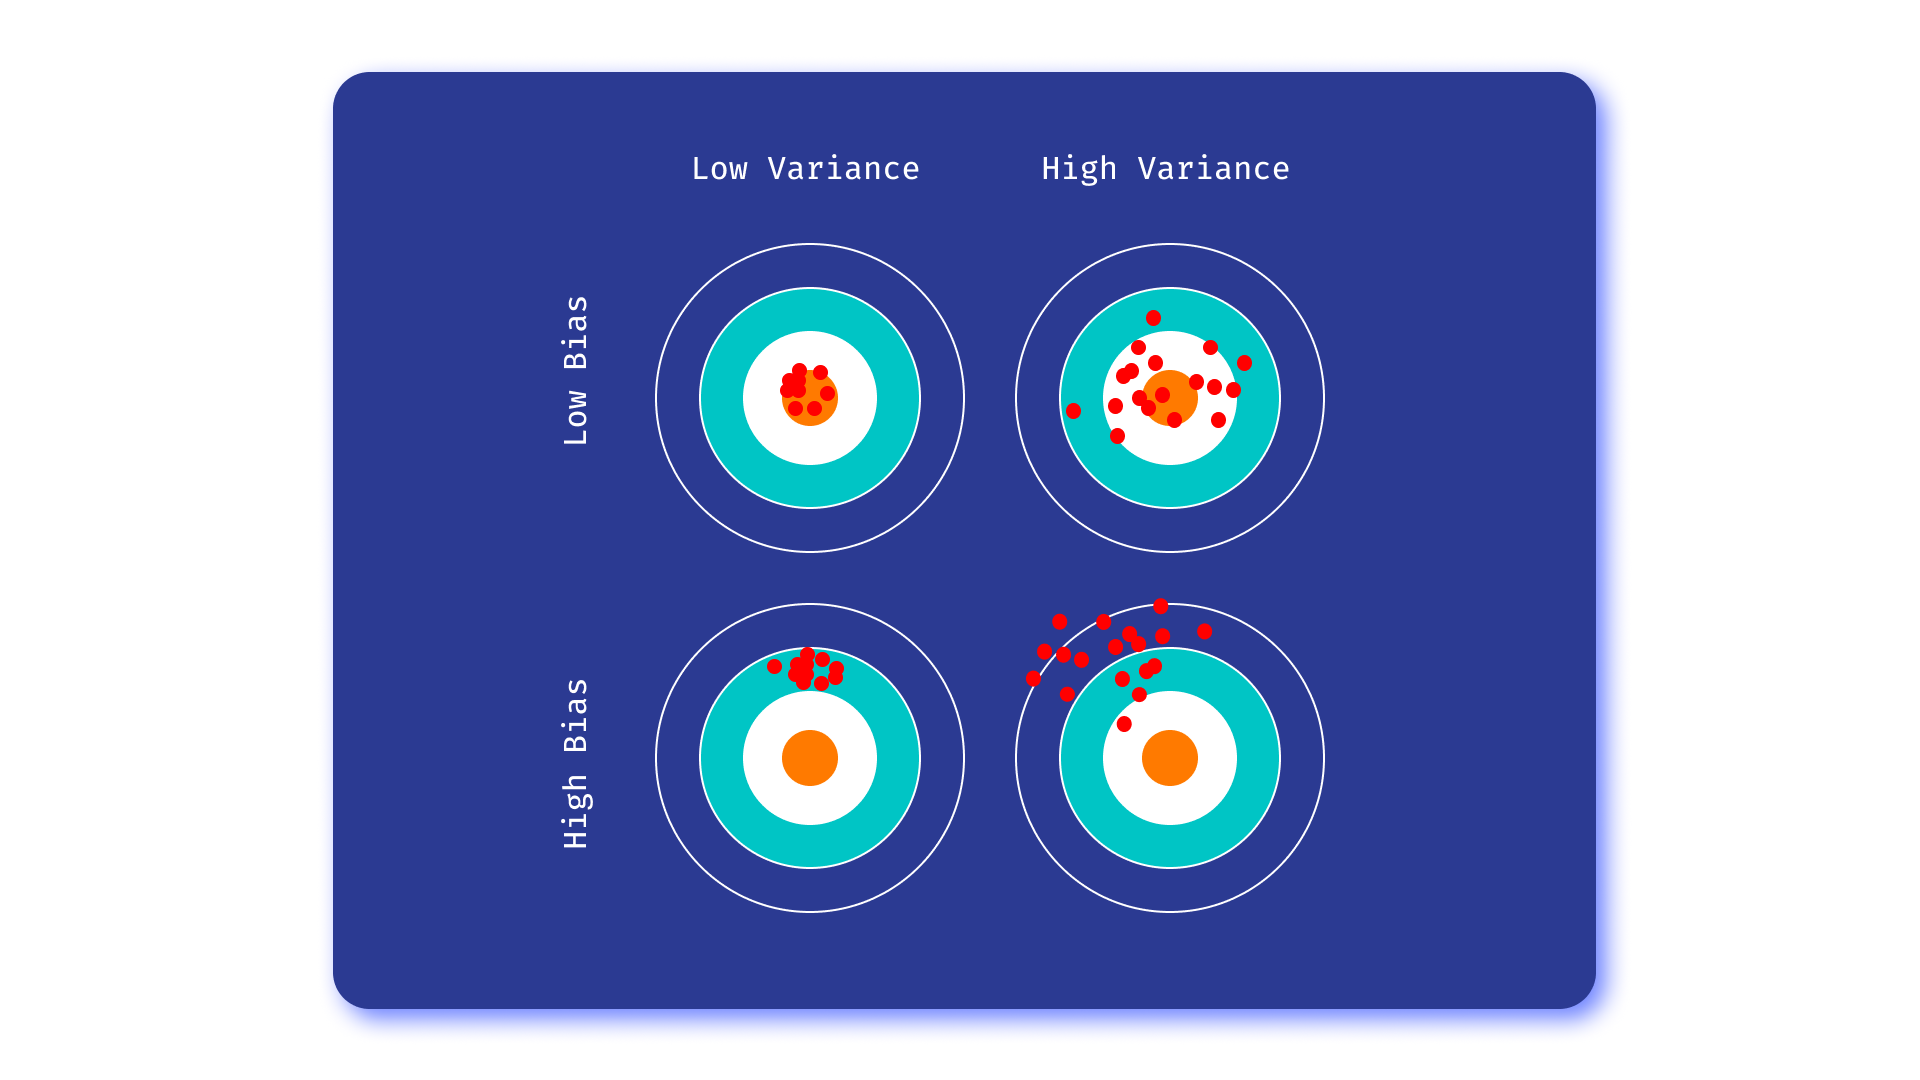

Отсюда возникает задача поиска оптимального соотношения между bias и variance. Понятно, что хотелось бы снизить оба этих показателя, но оказывается, что между ними существует определённая связь. И bias, и variance зависят от сложности выбранной модели. Усложнение модели приводит к росту разброса, а упрощение -- к росту смещения.

这就引发了寻找偏差和方差之间最佳关系的问题。显然，人们希望降低这两个指标，但事实证明它们之间存在一定的联系。偏差和方差都取决于所选模型的复杂性。增加模型的复杂性会导致散度的增加，而简化模型会导致偏差的增加。

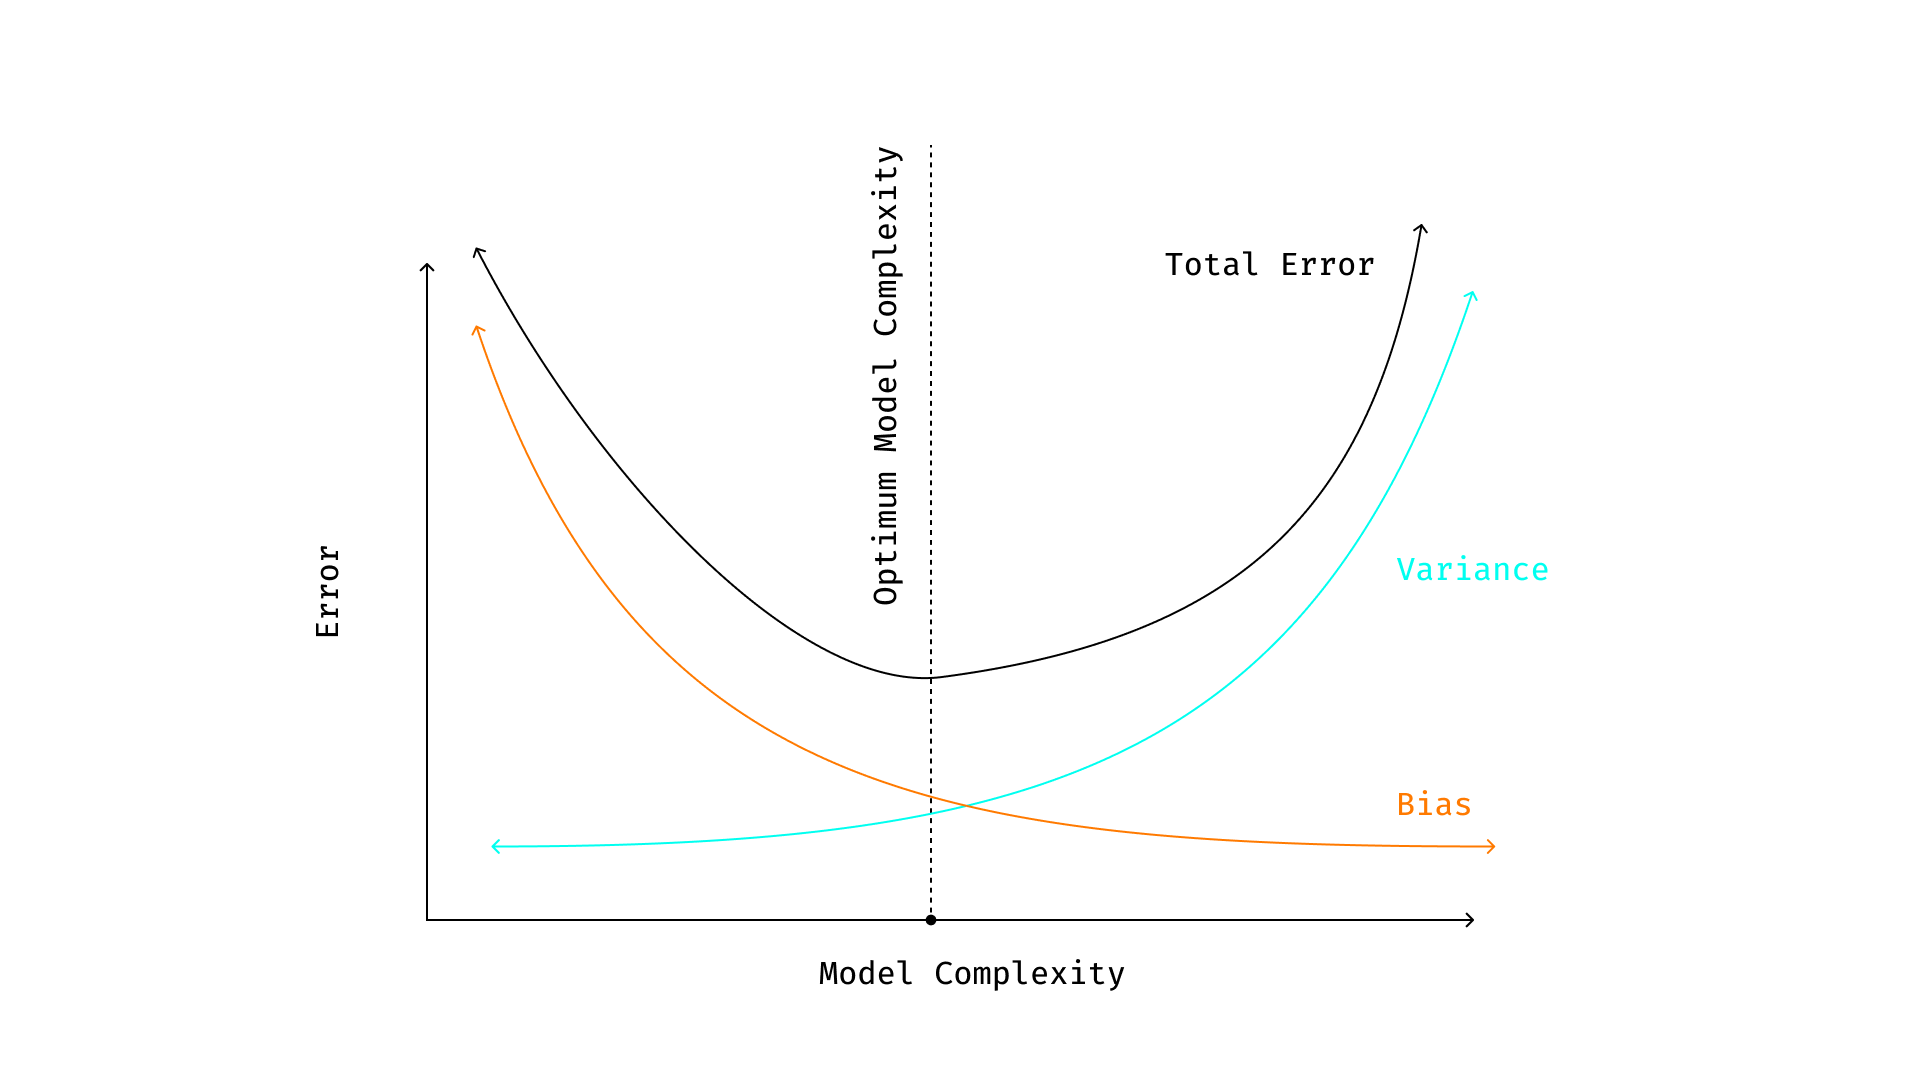

Поиск такого оптимума - это задача выбора оптимальной сложности модели, подбора гиперпараметров и т.п.

Тем не менее, оказывается, что существует довольно очевидный метод уменьшения variance при фиксированном bias. Пусть у нас есть $N$ немного отличающихся друг от друга алгоритмов одного класса. В случае, если отличия между ними действительно не очень сильные, их bias примерно одинаковый, то есть систематическая часть их ошибки близка. Пусть вместо предсказания одного из алгоритмов мы в том или ином виде будем рассматривать их совокупное предсказание. Например, усредним предсказание всех $N$ алгоритмов. Очевидно, bias такого объединенного алгоритма будет очень близок к bias каждого из исходных (базовых) алгоритмов. Variance же уменьшится, ведь мы теперь усредняем значения, случайным образом распределённые вокруг некоторой точки, что скорее всего поможет нам снизить отклонение от этой самой точки.

Таким образом, мы вновь приходим к идее ансамблирования, выразив её теперь в терминах разложения ошибки в смещение и разброс.

找到这样的最优解是一项选择模型最佳复杂度、选择超参数等的任务。

然而，事实证明存在一种相当明显的方法可以减少固定偏差下的方差。假设我们有$N$个同一类的略有不同的算法。如果它们之间的差异确实不是很强，那么它们的偏差就大致相同，也就是说，它们的误差的系统部分是接近的。我们不再预测其中一种算法，而是考虑以某种形式组合预测它们。例如，让我们对所有 $N$ 个算法的预测取平均值。显然，这种组合算法的偏差将非常接近每个原始（基础）算法的偏差。方差会减小，因为我们现在是对围绕某个点随机分布的值进行平均，这很可能会帮助我们减少与这个点的偏差。

因此，我们回到集成的想法，现在用将误差分解为偏差和扩散来表达。

# Простое голосование классификаторов

Пусть у нас есть некоторое количество не очень хороших моделей. Такие модели мы будем называть *базовыми*. Обозначим их за $b_1 ... b_n$.

Пусть стоит задача бинарной классификации, то есть нужно найти алгоритм $A: X $→$ Y = {-1,1}$ (То есть метки классов обозначены за 1 и -1).

Простым голосованием классификаторов назовем следующее правило выбора итогового ответа: $$A(x) = sign(\sum\limits_{i=1}^n b_i(x))$$

Если большинство классификаторов предложили в качестве ответа +1, итоговый алгоритм также предложит в качестве ответа +1, а если большинство сошлось на варианте -1, то и итоговый ответ будет таким.

_________________
_________________
### Важное замечание

Представим, что все используемые нами классификаторы дают один и тот же ответ для каждого из объектов в выборке. Отсюда следует, что и итоговый ансамблевый алгоритм будет давать точно такие же ответы. Такой случай не даст нам абсолютно никакого преимущества по сравнению с использованием любого из базовых классификаторов.

Отсюда следует важный вывод: модели, используемые в качестве базовых, должны быть **разными**.

Причем под разными подразумевается не обязательно использование разных моделей машинного обучения. Мы можем выбрать одни и те же модели, но обучить их с разными гиперпараметрами, на разных подвыборках и т.п.

Моделями в этом случае, скорее всего, будут ответы, отличающиеся в достаточной степени, чтобы собрать из них ансамбль.
___________________
_________________


分类器的简单投票

假设我们有许多不太好的模型。我们将此类模型称为*基础*。我们将它们表示为 $b_1 ... b_n$。

假设我们有一个二分类问题，即我们需要找到一个算法$A: X $→$ Y = {-1,1}$（即类标签指定为 1 和 -1）。

我们将以下选择最终答案的规则称为分类器的简单投票：$$A(x) = sign(\sum\limits_{i=1}^n b_i(x))$$

如果大多数分类器建议+1作为答案，那么最终算法也会建议+1作为答案；如果大多数人同意-1选项，那么最终答案将是相同的。

_________________
_________________
重要提示

让我们想象一下，我们使用的所有分类器对样本中的每个对象都给出相同的答案。因此，最终的集成算法将给出完全相同的答案。与使用任何基本分类器相比，这种情况对我们来说都没有任何优势。

由此得出一个重要的结论：用作基础模型的模型必须**不同**。

此外，我们所说的不同并不一定意味着使用不同的机器学习模型。我们可以选择相同的模型，但使用不同的超参数、在不同的子样本上等来训练它们。

在这种情况下，模型可能是具有足够差异的响应，从而形成一个整体。
___________________
_________________

Два основных типа ансамблевых моделей: cлучайный лес и градиентный бустинг. В них в качестве слабых моделей чаще всего берут деревья принятия решений. Выбор деревьев не случаен. В отличие от, например, линейных моделей, у деревьев для каждого отдельного слабого классификатора можно менять не только подвыборки наблюдений и признаков, но и другие параметры. Например, ограничить глубину дерева или минимальное число объектов в каждом узле. Поэтому деревьями получают гораздо больше моделей для решения одной и той же задачи. Усреднение работает лучше, когда модели отличаются и компенсируют ошибки друг друга. А вот усреднение похожих моделей с одинаковыми недостатками не приведёт к такому эффекту.

集成模型主要有两种类型：随机森林和梯度提升。其中，决策树通常被视为弱模型。树木的选择并不是随机的。例如，与线性模型不同，对于每个单独的弱分类器的树，不仅可以改变观测和特征的子样本，还可以改变其他参数。例如，限制树的深度或每个节点中的最小对象数量。因此，树会产生更多模型来解决同一个问题。当模型不同且能补偿彼此的错误时，平均法效果最佳。但对具有相同缺点的类似模型进行平均不会产生这样的效果。

# Случайный лес

Первый тип ансамбля моделей — случайный лес. Он генерирует множество различных независимых друг от друга деревьев слегка разными способами (берёт разные подвыборки, разные признаки), а на основании их ответов формирует итоговое решение. Алгоритм случайного леса усредняет ответы всех деревьев (в задаче регрессии) или выбирает голосованием (в классификации) тот ответ, который большинство деревьев в лесу считает правильным. Говоря об ансамблях моделей, применяют термин **бэггинг** (англ. bagging). Он означает усреднение моделей, обученных на разных подвыборках. А сам подход, при котором оценивают различные характеристики или прогнозы на основании множества различных подвыборок из исходной, называют **бутстреп** (англ. bootstrap).

При работе с Random Forest помните, что деревья обучаются *«параллельно»* — независимо друг от друга. Обучение каждого дерева не зависит от результатов других. Это концептуальное отличие случайного леса от градиентного бустинга.






随机森林

第一类模型集成是随机森林。它以略有不同的方式（采用不同的子样本、不同的特征）生成许多彼此独立的不同树，并根据它们的响应形成最终解决方案。随机森林算法对所有树的答案取平均值（在回归问题中）或对森林中大多数树都认为正确的答案进行投票（在分类问题中）。当谈论模型集合时，会使用术语**bagging**。它意味着对在不同子样本上训练的模型进行平均。这种方法本身称为**自举**，即根据来自原始的许多不同子样本来估计各种特征或预测。

使用随机森林时，请记住树是“并行”训练的，彼此独立。每棵树的学习都独立于其他树的结果。这是随机森林和梯度提升的概念区别。

### Метод случайных подпространств

Один из способов сделать базовые модели (деревья в нашем случае) как можно более разными - обучать их на случайно выбранных подвыборках признаков объектов.

随机子空间方法

使基础模型（在我们的例子中是树）尽可能多样化的一种方法是在随机选择的对象特征子样本上对它们进行训练。

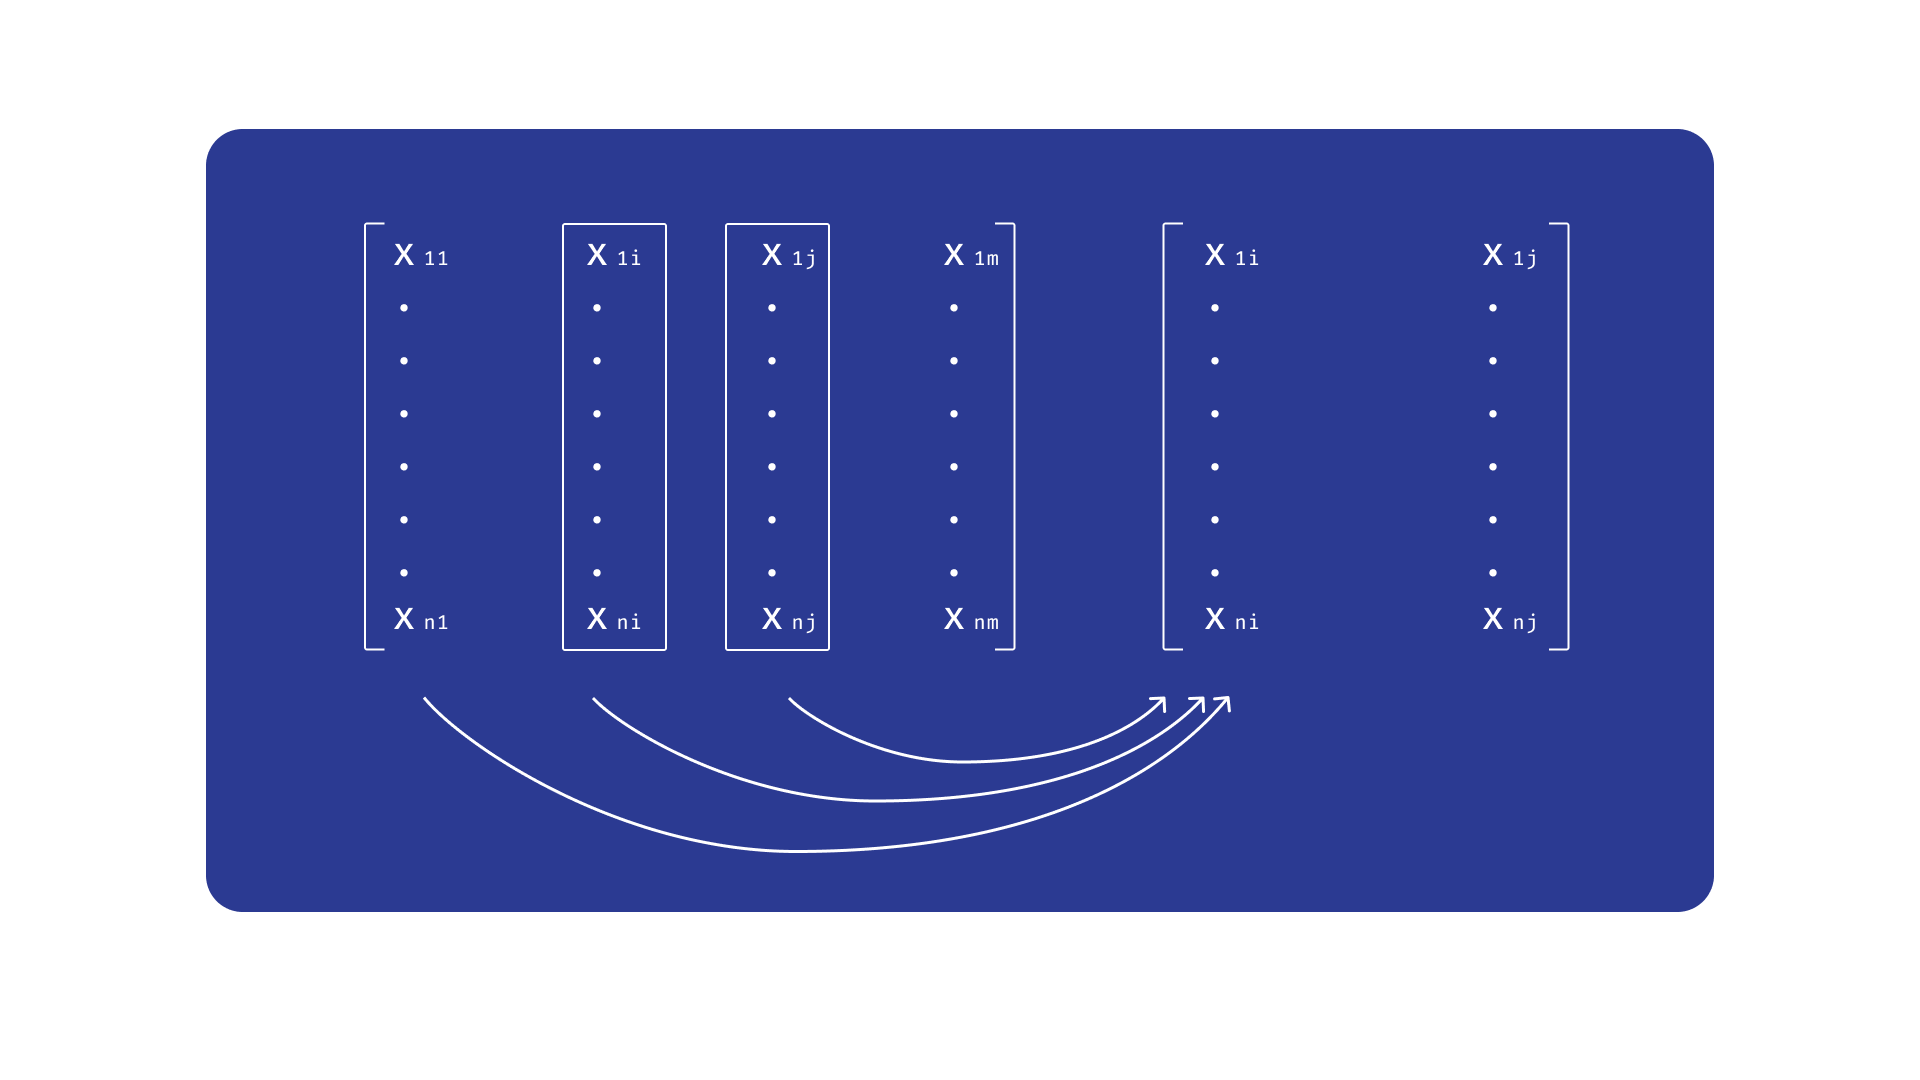


### Бэггинг
Бэггинг предполагает выбор случайных подвыборок самих объектов. Случайная подвыборка формируется с повторениями (то есть если мы выбрали некоторый объект из выборки, мы можем выбрать его еще раз. При таком подходе в подвыборку в среднем попадает около 63% объектов исходной выборки).



装袋

装袋涉及选择对象本身的随机子样本。通过重复形成随机子样本（即，如果我们已经从样本中选择了某个对象，则可以再次选择它。通过这种方法，平均而言，原始样本中大约 63％ 的对象会包含在子样本中）。

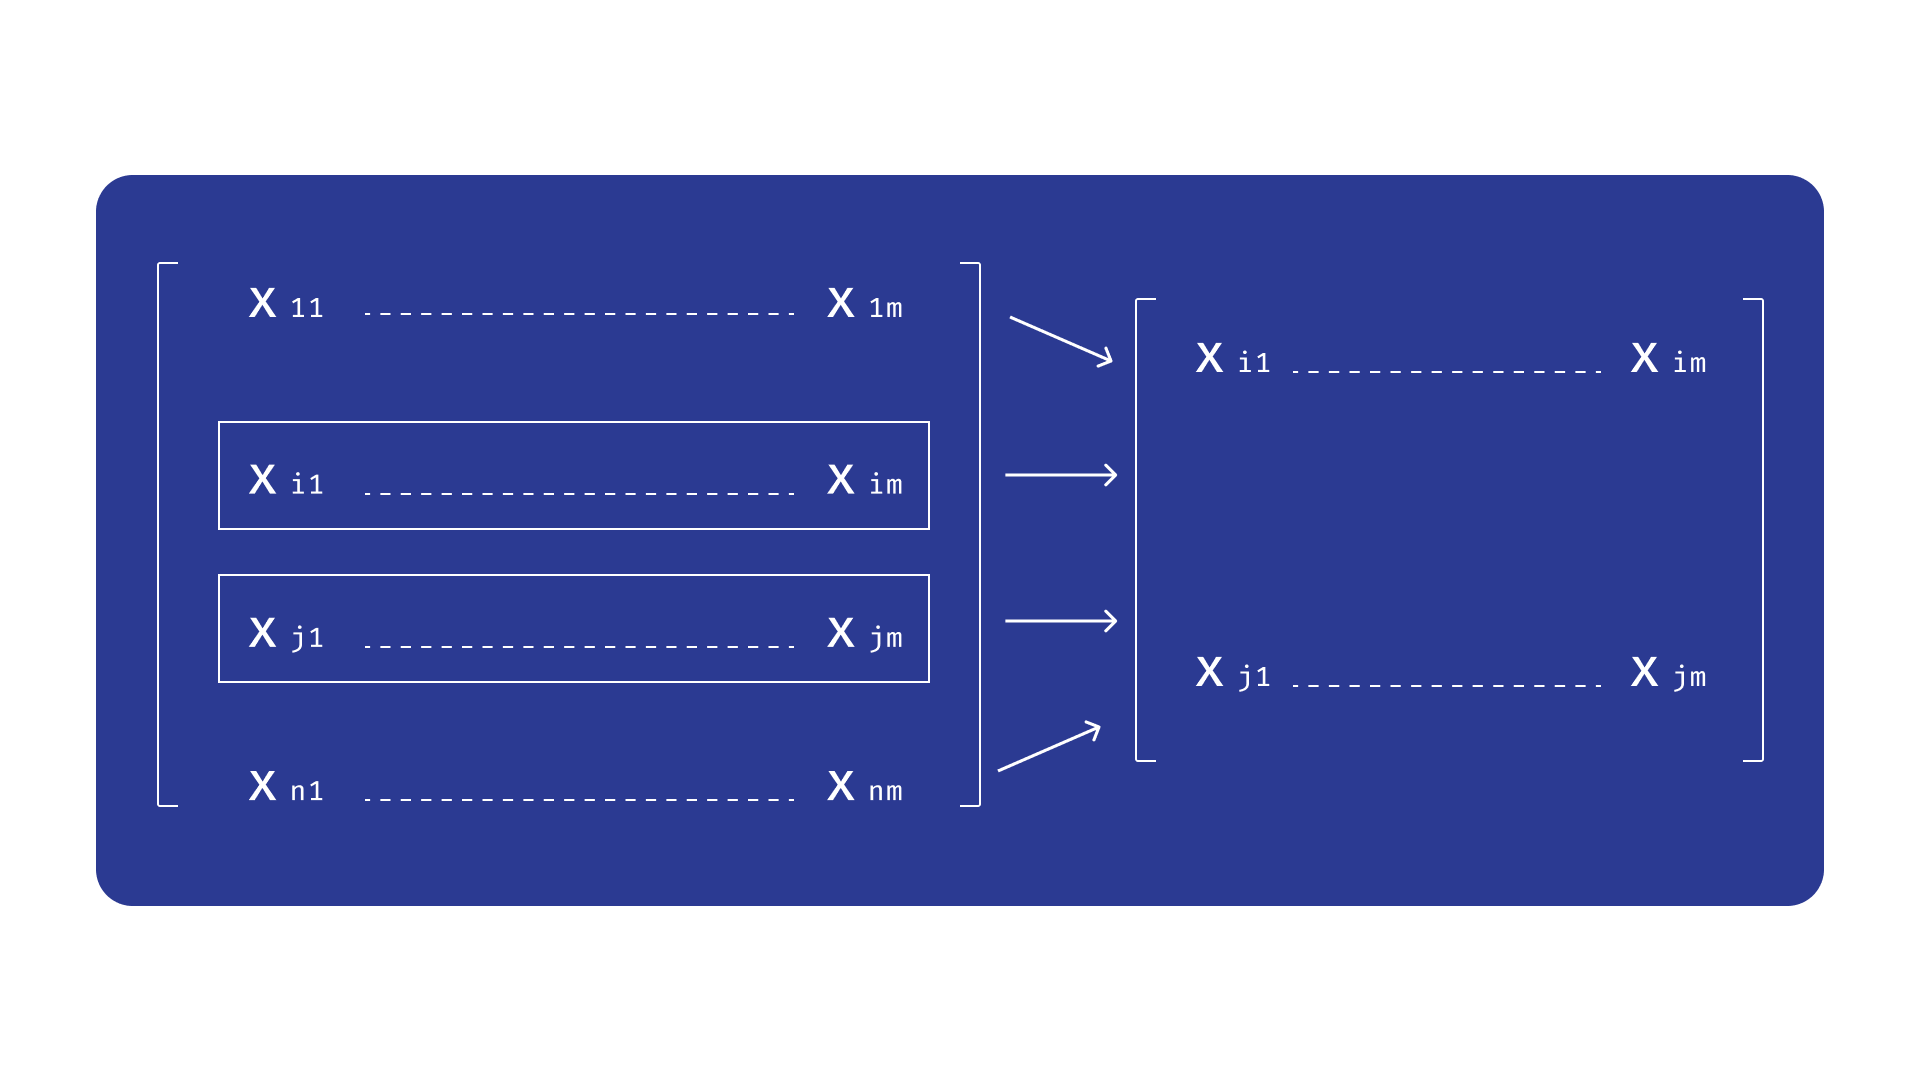


### Случайный лес
В рамках классического алгоритма случайного леса применяются оба этих подхода.


随机森林

在经典的随机森林算法中，这两种方法都会用到。

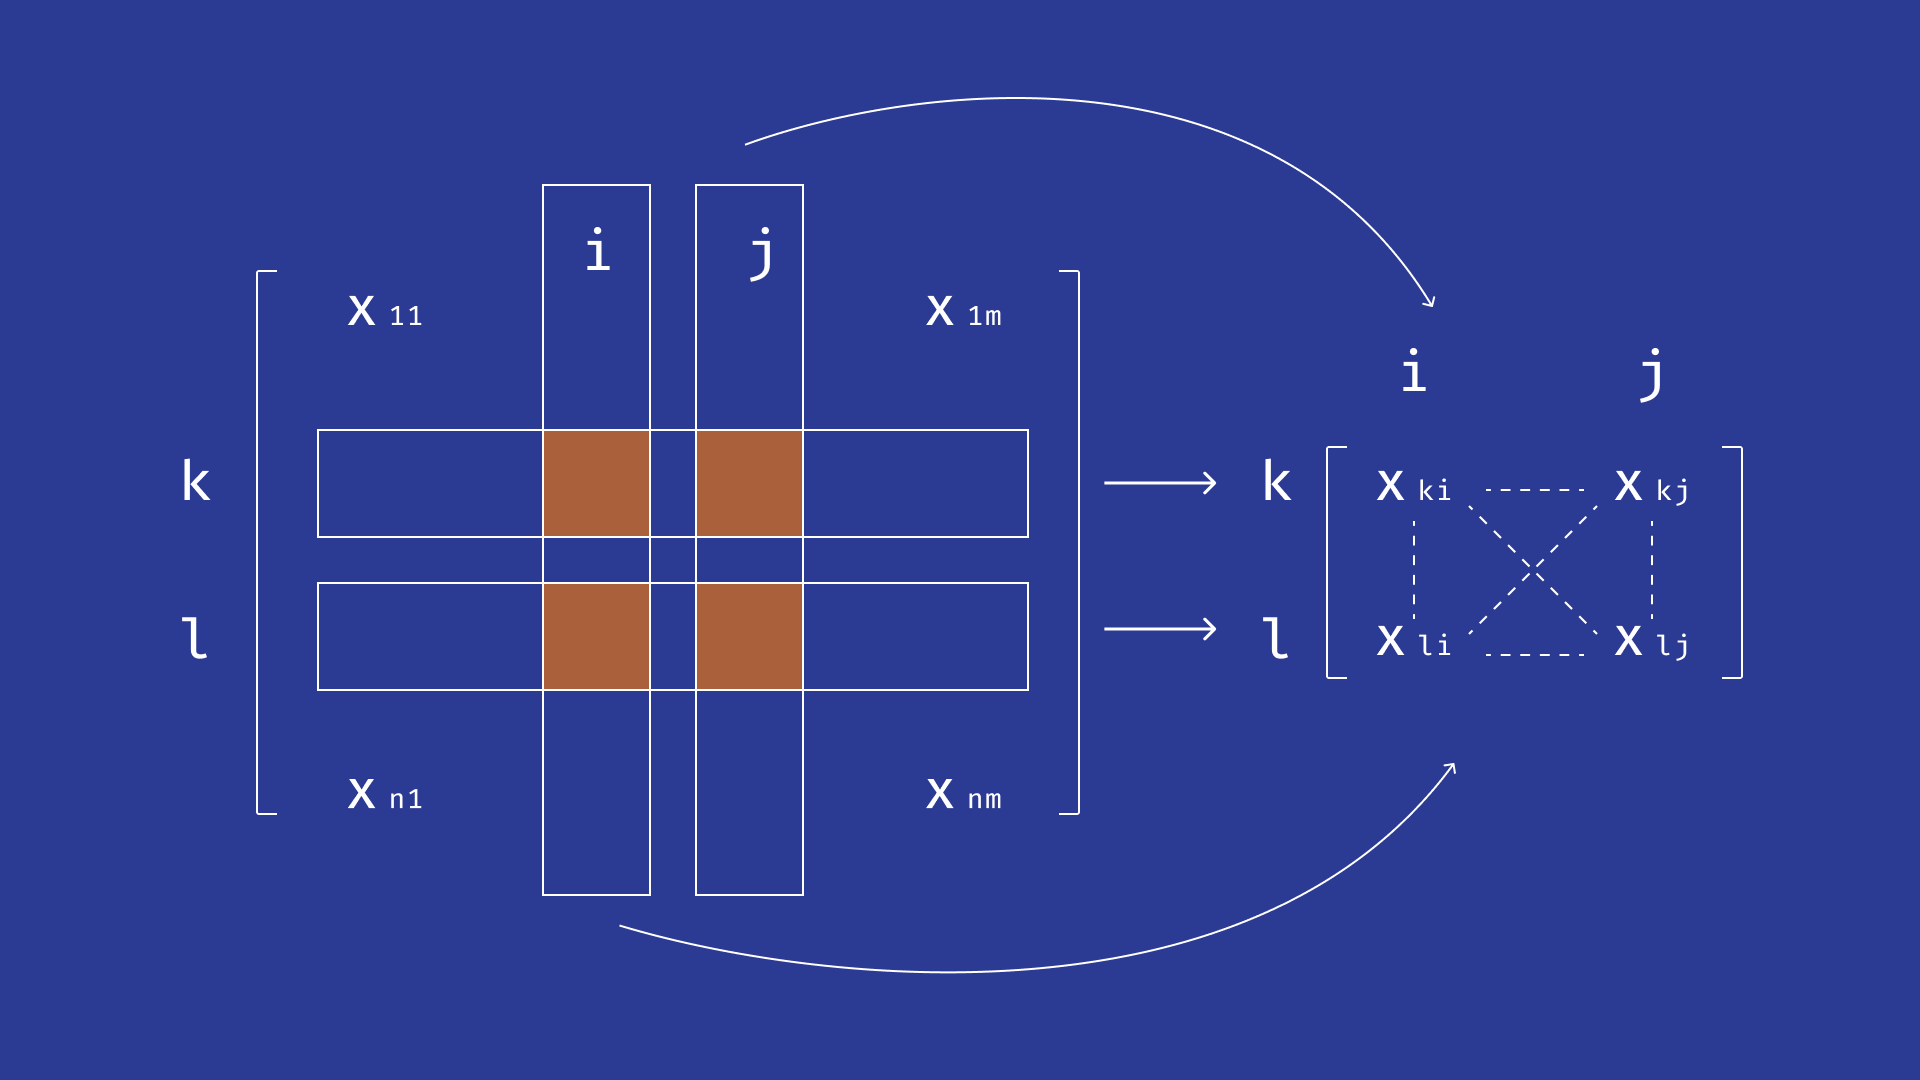

# Градиентный бустинг (англ. gradient boosting)
Фундаментально идея та же: собираем много простых моделей (деревьев), чтобы они компенсировали ошибки и случайности друг друга. Только в этом случае компенсация ошибок происходит не за счёт усреднения, а через обучение. В градиентном бустинге деревья обучаются последовательно: каждое следующее дерево строится с учётом результатов предыдущего. Вы уже знаете принцип работы градиентного спуска: когда, двигаясь в нужном направлении, последовательно на каждом следующем шаге стараются минимизировать ошибку. Идея градиентного бустинга аналогична: на определённом шаге есть модель, и она делает прогноз с какой-нибудь ошибкой. Тогда строят вторую модель, которая будет прогнозировать не исходную величину, а ошибку первой модели, и с учётом этого корректировать финальный прогноз. Третья модель спрогнозирует ошибку второй и так дальше. В финале прогнозируем конкретное наблюдение на основании всей этой последовательности. Говорим, что первая модель дала такой ответ, но к нему добавляем корректировку из второй, потом — из третьей и так, пока не дойдём до последней. Так на каждом следующем шаге (каждой следующей моделью) улучшают прогноз предыдущего. *Бустинг* означает «улучшение». А *градиентный бустинг* — «последовательное улучшение».

## Линейная композиция классификаторов

Технически градиентный бустинг строится принципиально иначе (по сравнению со случайным лесом).

Речь идет о линейной комбинации классификаторов.

Линейная комбинации - это выражение вида $$\sum\limits_{i=1}^nc_ib_i(x)$$

Вместе с тем, возможно, существует некоторое решающее правило $D$, которое определяет по этой сумме, каков же итоговый ответ (например, $D$ может быть сравнением указанной выше суммы с некоторым пороговым значением: если в сумме мы получили значение, превышающее порог, ответ 1, а иначе 0 (или -1) ).

Тогда наш ансамблевый алгоритм строится по правилу $$A(x) = D(\sum\limits_{i=1}^nc_ib_i(x))$$

Обучение такого алгоритма строится последовательно:

1. Сначала мы строим самый первый классификатор $b_1$. Здесь нет никаких хитростей, это просто самая обычная модель выбранного типа.

2. Пока мы не достигнем нужного качества, будем добавлять новые классификаторы $b_i$ к нашему ансамблю.

3. Пусть мы уже построили классификаторы $b_1 ... b_m$. Как нам добавить к ним $b_{m+1}$ ?

>Вспомним алгоритм градиентного спуска: если алгоритм $A$ параметризуется вектором параметров $\vec{w}$, то $\vec{w}_{n+1} = \vec{w}_n - α∇_wQ(x,\vec{w}) = \vec{w}_n - α\vec{g_n}$, где $α$ - это параметр, задающий размер градиентного шага.

> Наша же задача сформировать $A_{m+1} = \sum\limits_{i=1}^mc_ib_i(x) + c_{m+1}b_{m+1} = A_m + c_{m+1}b_{m+1}$
> Еще раз: $$\vec{w}_{n+1} = \vec{w}_n - α\vec{g_n}$$ и $$A_{m+1} = A_m + c_{m+1}b_{m+1}$$
> почему бы нам не строить $b_{m+1}$ так, чтобы он приближал вектор антиградиента $-\vec{g_m}$? Тогда мы получаем аналог градиентного спуска, распространенный на ансамбли.

> На человеческом языке это значит, что каждый новый классификатор мы будем строить так, чтобы он приближал ошибки предыдущего и исправлял их.


梯度提升

从根本上来说，想法是一样的：我们收集许多简单模型（树），以便它们相互补偿错误和随机性。只有在这种情况下，错误的补偿不是通过平均而是通过学习来实现的。在梯度提升中，树是按顺序训练的：每个后续树的构建都会考虑到前一棵树的结果。您已经了解梯度下降的原理：当朝着正确的方向移动时，它们会不断尝试在每一步中最小化错误。梯度提升 (gradient boosting) 的思想是类似的：在某一步骤有一个模型，它会做出带有一些误差的预测。然后，他们建立第二个模型，该模型预测的不是原始值，而是第一个模型的误差，并考虑到这一点，调整最终预测。第三个模型将预测第二个模型的误差，依此类推。最后，我们根据整个序列预测特定的观察结果。我们说第一个模型给出了这个答案，但是我们在它上面添加了第二个模型的修正，然后是第三个模型的修正，依此类推，直到得到最后一个模型。因此，在每个后续步骤（每个后续模型）中，前一个步骤的预测都会得到改进。 *Boosting* 的意思是“改善”。并且*梯度提升*是“逐步改进”。

分类器的线性组合

从技术上讲，梯度提升的构造有着根本的不同（与随机森林相比）。

我们正在讨论分类器的线性组合。

线性组合是形式为 $$\sum\limits_{i=1}^nc_ib_i(x)$$ 的表达式

同时，可能存在一些决策规则 $D$ 根据这个总和来确定最终答案是什么（例如，$D$ 可能是上述总和与某个阈值的比较：如果总和中我们得到一个超过阈值的值，则答案为 1，否则为 0（或 -1））。

然后我们的集成算法根据规则 $$A(x) = D(\sum\limits_{i=1}^nc_ib_i(x))$$ 构建

这种算法的训练是按顺序构建的：

1. 首先我们建立第一个分类器$b_1$。这里没有什么技巧，它只是所选类型中最常见的模型。

2. 直到我们达到所需的质量，我们将向我们的组合中添加新的分类器$b_i$。

3. 假设我们已经建立了分类器$b_1...b_m$。我们如何将 $b_{m+1}$ 添加到它们中？

>回想一下梯度下降算法：如果算法$A$由参数向量$\vec{w}$参数化，则$\vec{w}_{n+1} = \vec{w}_n - α∇_wQ(x,\vec{w}) = \vec{w}_n - α\vec{g_n}$，其中$α$是指定梯度步骤大小的参数。

> 我们的任务是形成 $A_{m+1} = \sum\limits_{i=1}^mc_ib_i(x) + c_{m+1}b_{m+1} = A_m + c_{m+1}b_{m+1}$
> 再次：$$\vec{w}_{n+1} = \vec{w}_n - α\vec{g_n}$$ 且 $$A_{m+1} = A_m + c_{m+1}b_{m+1}$$
> 为什么我们不构造 $b_{m+1}$ 以便它近似于反梯度向量 $-\vec{g_m}$？然后我们得到了扩展到集合的梯度下降的类似物。

> 用人类语言来说，这意味着我们将以这样一种方式构建每个新的分类器，使其近似于前一个分类器的错误并进行纠正。

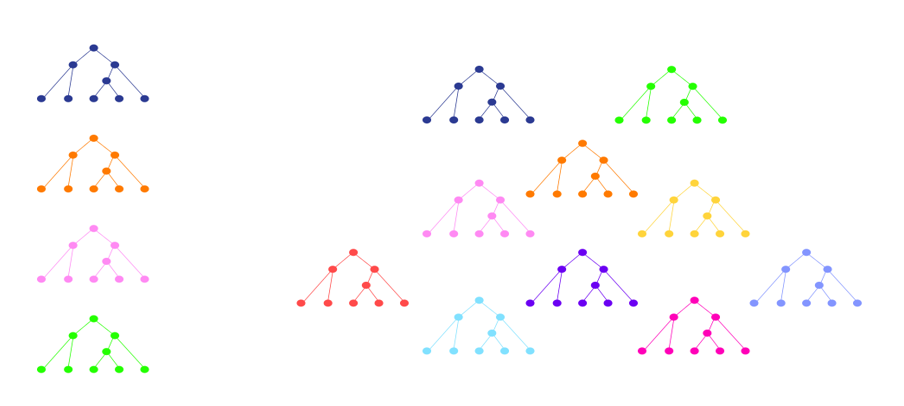

# Реализация ансамблей деревьев
Случайный лес в `sklearn` реализован в модуле `ensemble`. Из этого модуля чаще всего применяют алгоритмы `RandomForestClassifier()`и `RandomForestRegressor()` для задач классификации и регрессии, соответственно. Синтаксис объявления, обучения и прогнозирования на примере задачи классификации:

树集成的实现

`sklearn` 中的随机森林是在 `ensemble` 模块中实现的。该模块中最常用的算法是`RandomForestClassifier()`和`RandomForestRegressor()`，分别用于分类和回归问题。使用分类问题的示例的公告、训练和预测的语法：

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 定义一个基于随机森林算法的新模型的算法
rf_model = RandomForestClassifier(max_depth=2, n_estimators=2)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(x_test)

In [ ]:
accuracy_score(y_pred, y_test)

0.9473684210526315

Тут при объявлении модели мы задали `n_estimators` — число деревьев, на основании которых будем строить лес. При этом другие параметры дерева — например, глубину дерева `max_depth`, размер подвыборки признаков `max_features`, минимальное количество объектов в узле `min_samples_leaf` — мы не задавали и оставили их по умолчанию. На практике вы можете экспериментировать с этими значениями и смотреть, как это влияет на результат.

Градиентный бустинг в `sklearn`реализован в модуле `ensemble`. В нём алгоритмы `GradientBoostingClassifier()` и `GradientBoostingRegressor()` для задач классификации и регрессии, соответственно. Синтаксис на примере задачи классификации:

在这里，在声明模型时，我们指定了“n_estimators”——我们将在此基础上构建森林的树的数量。同时，我们没有设置其他树参数——例如树深度“max_depth”、特征子样本的大小“max_features”、节点中的最小对象数“min_samples_leaf”——并保留它们的默认设置。在实践中，您可以尝试这些值并看看它如何影响结果。

`sklearn` 中的梯度提升是在 `ensemble` 模块中实现的。它包含分别用于分类和回归问题的 `GradientBoostingClassifier()` 和 `GradientBoostingRegressor()` 算法。以分类问题为例的语法：

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# 让我们定义一个基于梯度提升算法的新模型算法
gb_model = GradientBoostingClassifier(n_estimators=100)
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(x_test)

In [ ]:
accuracy_score(y_pred, y_test)

0.9707602339181286

# Резюме
1. Использование ансамблевых алгоритмов может существенным образом улучшить качество классификации или регрессии.
2. В качестве базовых алгоритмов необходимо использовать отличающиеся друг от друга модели.
3. Существует 2 наиболее популярных вида ансамблей - *градиентный бустинг* и *случайный лес*. Оба реализованы на *решающих деревьях*.

概括
1. 使用集成算法可以显著提高分类或回归的质量。
2. 需要使用不同的模型作为基础算法。
3. 最流行的集成类型有两种——*梯度提升*和*随机森林*。两者都是在*决策树*上实现的。

# Примеры
Рассмотрим следующие примеры применения популярных ансамблевых алгоритмов:

- Задача предсказания стоимости недвижимости по описанию района на основе датасета california_housing
- Синтетическую двумерную задачу бинарной классификауции с визуализацией полученной разделяющей поверхности
- Задачу классификации изображений рукописных цифр из датасета MNIST
________________________________________________

示例

让我们考虑以下流行集成算法的应用示例：

- 基于 california_housing 数据集，根据区域描述预测房地产价值的任务
- 合成二维二元分类问题并对所得分割面进行可视化
- 对 MNIST 数据集中的手写数字图像进行分类的任务
________________________________________________

## 1. California Housing

Датасеты типа "housing" достаточно популярны в Data Science. Тематика таких датасетов - предсказание стоимости жилья по описанию района, которое обычно немного варьируется, но имеет много общих черт в различных датасетах такого типа. К таким датасетам относятся популярные датасеты Boston Housing, Kentucky Housing, Melburn Housing и т.п. Такие компании, как Циан или Авито разработали свои продукты во многом на основе именно таких датасетов.

Мы же в данном примере рассмотрим датасет California Housing.
Приведём его оригинальное описание.
____________________________________________________


California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block group is the smallest geographical unit for which the U.S.
Census Bureau publishes sample data (a block group typically has a population
of 600 to 3,000 people).

An household is a group of people residing within a home. Since the average
number of rooms and bedrooms in this dataset are provided per household, these
columns may take surpinsingly large values for block groups with few households
and many empty houses, such as vacation resorts.

It can be downloaded/loaded using the
:func:`sklearn.datasets.fetch_california_housing` function.

.. topic:: References

    - Pace, R. Kelley and Ronald Barry, Sparse Spatial Autoregressions,
      Statistics and Probability Letters, 33 (1997) 291-297

1. 加州住房

住房数据集在数据科学中非常流行。此类数据集的主题是根据社区描述来预测房价，社区描述通常略有不同，但此类不同数据集具有许多共同特征。这些数据集包括流行的数据集波士顿住房、肯塔基住房、梅尔本住房等。Cian 和 Avito 等公司主要基于这些数据集开发了他们的产品。

在这个例子中，我们将考虑加州住房数据集。
这是其原始描述。
_____________________________________________________


加州住房数据集

--------------------------------------

**数据集特征：**

:实例数：20640

:属性数量：8 个数字、预测属性和目标

:属性信息:
- 街区组中 MedInc 收入中位数
- HouseAge 街区组中房屋年龄中位数
- AveRooms 每户平均房间数
- AveBedrms 每户平均卧室数量
- 人口街区组人口
- AveOccup 平均家庭成员数
- 纬度块组纬度
- 经度块组长度

：缺少属性值：无

该数据集是从 StatLib 存储库获得的。
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

目标变量是加州各地区的房屋中位价，
以数十万美元（100,000 美元）表示。

该数据集来自 1990 年美国人口普查，每个人口普查使用一行
块组。街区组是美国的最小地理单位。
人口普查局发布样本数据（一个街区通常有
（从 600 人增加到 3,000 人）。

家庭是居住在一个家里的一群人。由于平均
本数据集中的房间和卧室数量按家庭提供，这些
对于家庭较少的街区组，列可能会取非常大的值
以及许多空置房屋，例如度假村。

可以使用
：func：`sklearn.datasets.fetch_california_housing` 函数。

.. 主题:: 参考文献

- Pace、R. Kelley 和 Ronald Barry，《稀疏空间自回归》，
统计与概率快报，33 (1997) 291-297

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()

X, y = housing.data, housing.target
X_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=True, random_state=42
)
X.shape

(20640, 8)

Для решения этой задачи воспользуемся моделью регрессии на основе градиентного бустинга. Выберем популярную реализацию градиентного бустинга из библиотеки `xgboost`

________________________
**Справка**

--------------
На текущий момент существует множество различных имплементаций алгоритма градиентного бустинга. Среди них можно выделить три наиболее популярные реализации:

* `XGBoost` - библиотека 2014 года, разработанная Тяньци Ченом и исследовательской группой DMLC. Изначально разработан в рамках решения соревнования  Higgs Machine Learning Challenge, где этот алгоритм показал чрезвычайную эффективность, заняв первое место. После этого сообщество заинтересовалось `xgboost`, а его имплементации были реализованы для таких языков программирования, как Python, R, Java, Scala, Julia, Perl и др. (https://xgboost.ai/)
* `Catboost` - проект 2017 года. Исчерпывающее описание `catboost` предлагает Википедия:

*Открытая программная библиотека, разработанная компанией Яндекс и реализующая уникальный патентованный алгоритм построения моделей машинного обучения, использующий одну из оригинальных схем градиентного бустинга. Основное API для работы с библиотекой реализовано для языка Python, также существует реализация для языка программирования R* (c)Wikipedia

* `Lightgbm` - проект 2016 года, разработанный компанией *Microsoft*. По сравнению с двумя приведёнными выше фреймворками, несколько сложен в использовании, хотя некоторые специалисты отмечают его особенную эффективность.

Наиболее популярным выбором "по умолчанию" на сегодняшний день, пожалуй, является именно `xgboost`. В общем и целом, выбор конкретного фреймворка - это дело вкуса.
_____________________

Тройка основных гиперпараметров алгоритма градиентного бустинга - это:
* n_estimators (число деревьев в ансамбле)
* max_depth (**максимальная** глубина каждого из деревьев в ансамбле)
* learning_rate (см. Лекция 3, градиентный спуск)

Интерфейс `xgboost` стандартизирован, то есть очень похож на интерфейс `sklearn`. Обучение моделей также производится при помощи вызова функции `.fit(X,y)`, а предсказание - при помощи функции `.predict(X)` или же `.predict_proba(X)`

为了解决这个问题，我们将使用基于梯度提升的回归模型。我们从“xgboost”库中选择一个流行的梯度提升实现

______________________________________
**参考**

--------------
目前，梯度提升算法有很多不同的实现。其中，最流行的实现有三种：

* `XGBoost` 是 Tianqi Chen 和 DMLC 研究团队于 2014 年开发的一个库。该算法最初是作为希格斯机器学习挑战赛的一部分开发的，表现出非凡的性能，赢得了第一名。此后，社区对`xgboost`产生了兴趣，并针对Python，R，Java，Scala，Julia，Perl等编程语言进行了实现（https://xgboost.ai/）
* `Catboost` 是 2017 年的项目。维基百科对“catboost”提供了全面的描述：

*Yandex 开发的开源软件库，使用原始梯度增强方案之一实现构建机器学习模型的独特专利算法。该库的主要 API 是针对 Python 语言实现的，另外还有一个针对 R* 编程语言的实现 (c)Wikipedia

* `Lightgbm` 是 *Microsoft* 于 2016 年开发的一个项目。与上面提到的两个框架相比，它的使用有些困难，尽管一些专家指出了它的特殊有效性。

当今最流行的“默认”选择可能是“xgboost”。一般来说，选择特定的框架是一个个人喜好的问题。
_____________________

In [ ]:
import xgboost
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error

xgb_reg = XGBRegressor(n_estimators=10, max_depth=5, learning_rate=0.4)

In [ ]:
xgb_reg.fit(X_train, y_train)
preds = xgb_reg.predict(x_test)

r2 = r2_score(y_test, preds)
mean_absolute_percentage_error(y_test, preds)

0.2180191181662406

In [ ]:
r2

0.777403998271669

Для сравнения построим одно бинарное дерево:

为了进行比较，我们构造一棵二叉树：

In [ ]:
from sklearn.tree import DecisionTreeRegressor

reg = DecisionTreeRegressor(max_depth=5).fit(X_train, y_train)
preds_tree = reg.predict(x_test)

r2_score(y_test, preds_tree)

0.6029986793705844

In [ ]:
mean_absolute_percentage_error(y_test, preds_tree)

0.32935074797935937

Изобразим полученный результат в координатах предсказание-таргет

让我们用预测目标坐标来表示得到的结果。

Text(0, 0.5, 'Bullet')

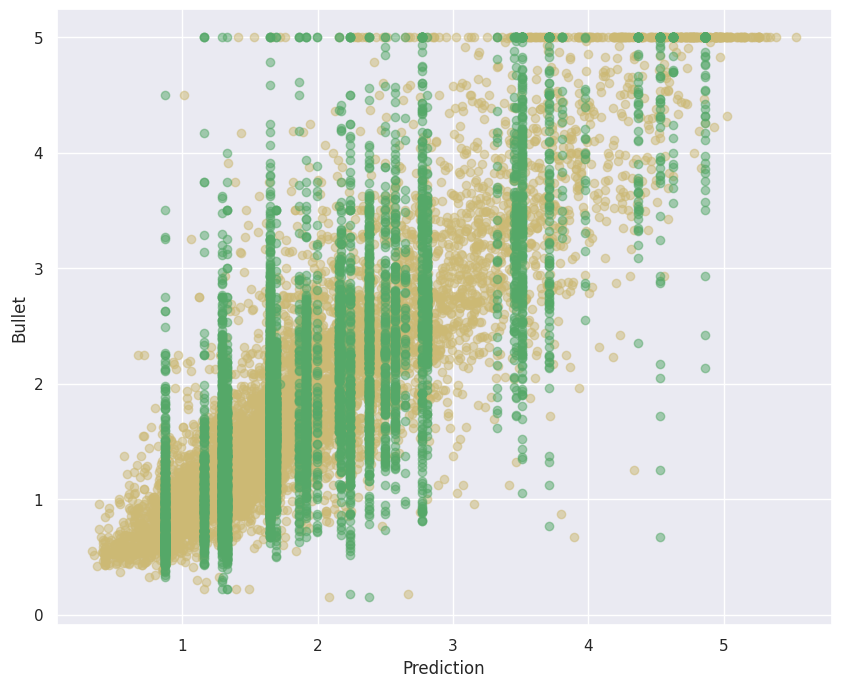

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

plt.figure(figsize=(10, 8))
plt.scatter(preds, y_test, label="Grad Boosting", c="y", alpha=0.5)
plt.scatter(preds_tree, y_test, label="Tree", c="g", alpha=0.5)
plt.xlabel("Prediction")
plt.ylabel("Bullet")

На этой визуализации хорошо заметно, что решающее дерево способно давать лишь один прогноз из определенного дискретного набора, в то время, как градиентный бустинг даёт непрерывный результат. Еще лучше это будет заметно, если уменьшить значение max_depth

这个可视化清楚地表明，决策树只能从给定的离散集合中产生一个预测，而梯度提升产生连续的结果。如果降低 max_depth 值，这种情况会更加明显。

Для лучшего понимания ситуации можем вывести гистограмму распределения ошибки предсказания

为了更好地理解情况，我们可以展示预测误差分布的直方图

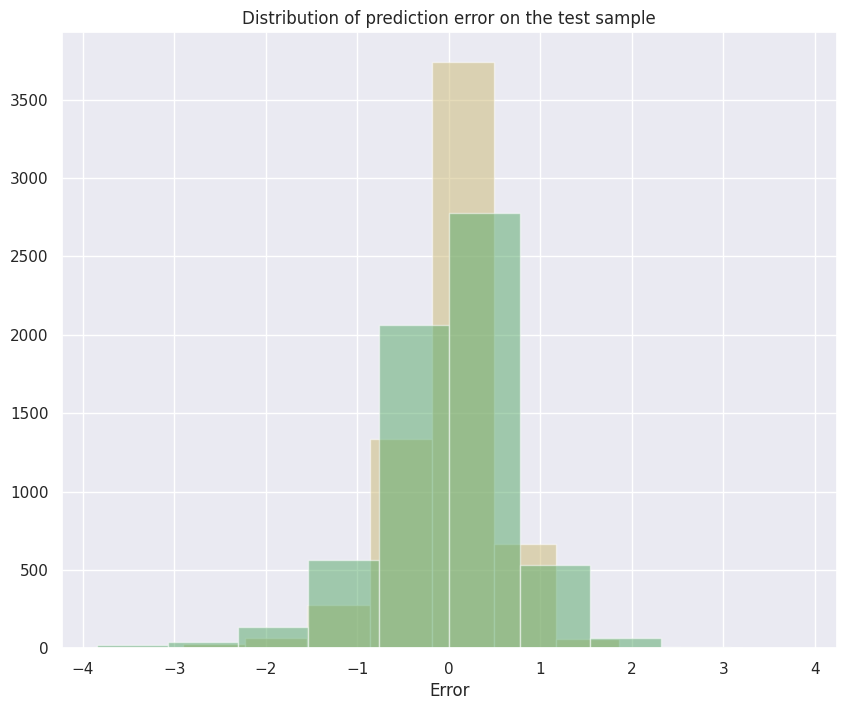

In [ ]:
ae = preds - y_test
ae_tree = preds_tree - y_test
plt.figure(figsize=(10,8))
plt.title('Distribution of prediction error on the test sample')
plt.xlabel('Error')
h = plt.hist(ae, alpha=0.5, color='y')
h = plt.hist(ae_tree, alpha=0.5, color='g')

In [ ]:
(ae**2).mean()

np.float64(0.2921661801074385)

In [ ]:
(ae_tree**2).mean()

np.float64(0.5210801561811792)

In [ ]:
ae.std()

np.float64(0.5405239086381965)

In [ ]:
ae_tree.std() # 按列计算标准差

np.float64(0.7218491942877675)

Видно также, что дисперсия ошибки предсказания решающего дерева выше, чем у ансамбля, среднеквадратичная ошибка также лучше у градиентного бустинга. В целом, оба алгоритма показали себя на достаточно высоком уровне.

还可以看出，决策树的预测误差的方差比集成的要高，并且均方误差对于梯度提升也更好。总体来说，两种算法的表现都相当高。

## 2. Random Forest для решения задачи бинарной классификации

Рассмотрим теперь пример применения случайного леса. Основная задача этого примера - продемонстрировать типичный вид разделяющей классы поверхности, формируемой этим алгоритмом.

Алгоритм случайного леса возьмём из модуля `sklearn.ensemble`. Для задачи классификации воспользуемся классом `RandomForestClassifier` указанного модуля.

2. 随机森林用于解决二元分类问题

现在让我们考虑一个随机森林应用的例子。本例的主要目的是展示该算法生成的类分离面的典型形式。

我们将从“sklearn.ensemble”模块中获取随机森林算法。对于分类任务，我们将使用指定模块的“RandomForestClassifier”类。

In [ ]:
# 将点添加到第一类的平面
np.seed = 10
train_data = np.random.normal(size=(50, 2))
train_data = np.r_[train_data, np.random.normal(size=(50, 2), loc=0.5, scale=2)]
train_labels = np.zeros(100)

# 添加第二个类别的点
train_data = np.r_[train_data, np.random.normal(size=(100, 2), loc=4, scale=2)]
train_labels = np.r_[train_labels, np.ones(100)]

CPU times: user 2.58 s, sys: 907 ms, total: 3.49 s
Wall time: 3.47 s


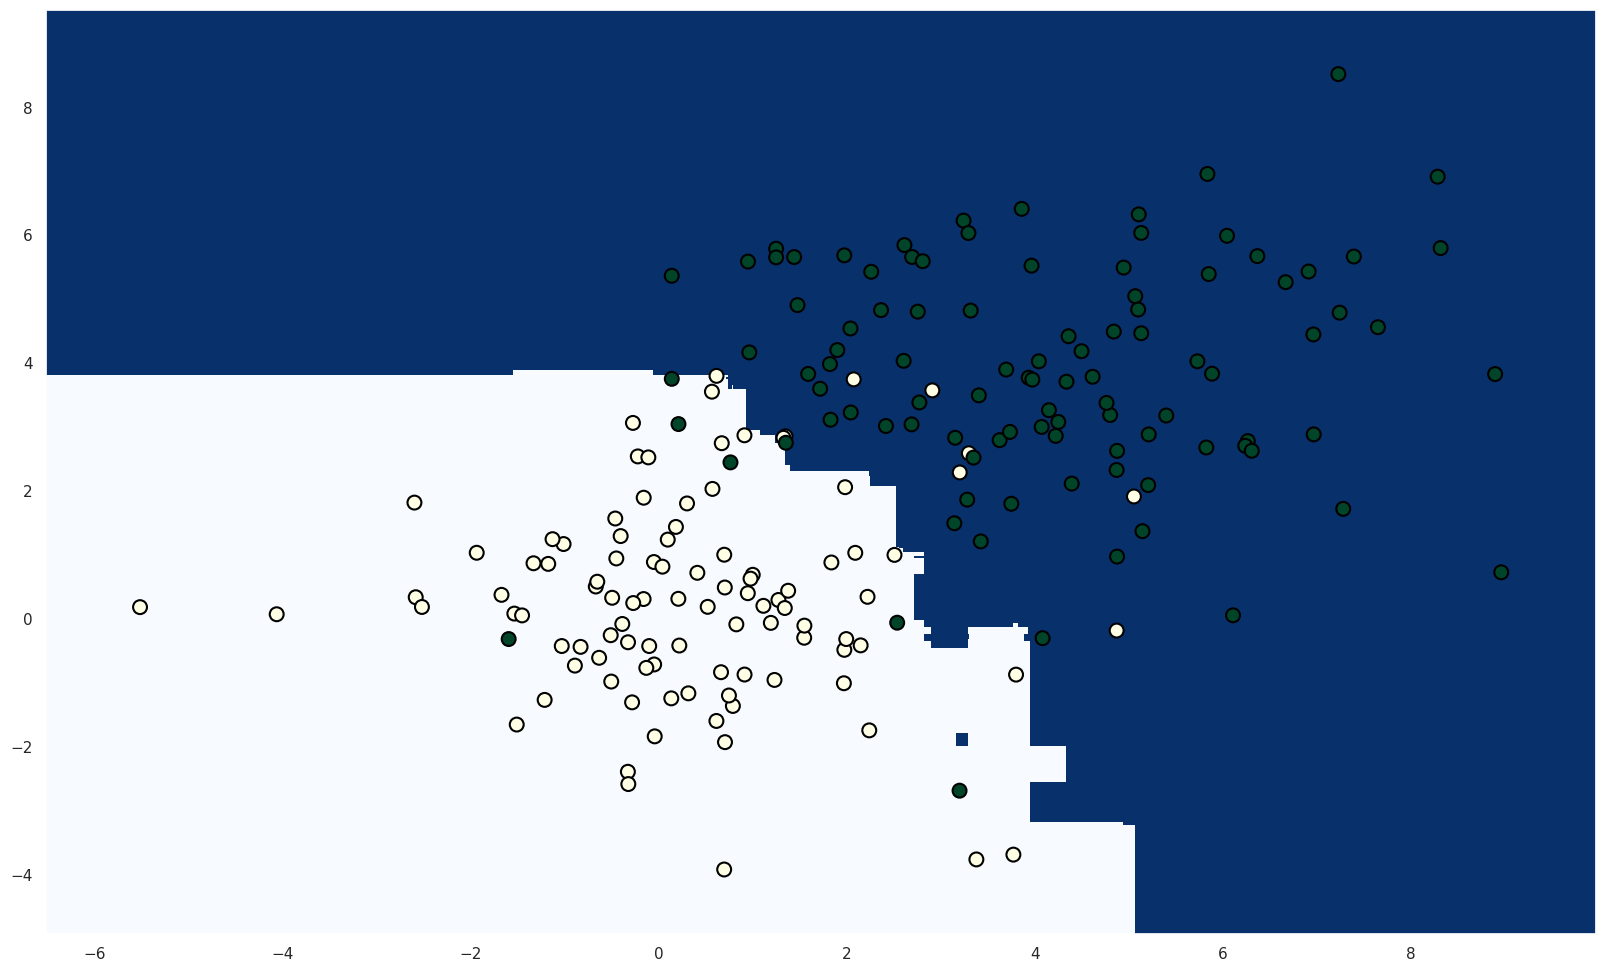

In [ ]:
%%time
from sklearn.ensemble import RandomForestClassifier

# 训练算法
rf_model = RandomForestClassifier(n_estimators=50, max_depth=3)
rf_model.fit(train_data, train_labels)

# 分割面
def get_grid(data):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    return np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))


xx, yy = get_grid(train_data)
predicted = rf_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(20, 12))
plt.pcolormesh(xx, yy, predicted, cmap="Blues")
plt.scatter(
    train_data[:, 0],
    train_data[:, 1],
    c=train_labels,
    s=100,
    cmap="YlGn",
    edgecolors="black",
    linewidth=1.5,
);

## 3. MNIST

`MNIST` - один из самых популярных датасетов Computer Vision. В этом датасете содержится набор изображений рукописных цифр, представленных в виде массивов размерности $28 × 28$. Каждый элемент этого массива представляет из себя описание пикселя в виде значения интенсивности его цвета. Эти матрицы разворачиваются в соответствующие векторы размерности 784, таким образом, получается векторное описание каждой картинки. На этих векторах и обучается алгоритм многоклассовой классификации.

Ради разнообразия воспользуемся на этот раз реализацией градиентного бустинга из библиотеки `sklearn`. Аргумент `verbose` позволяет настроить вывод статистической информации в процессе построения деревьев.

3. MNIST

`MNIST` 是最流行的计算机视觉数据集之一。该数据集包含一组以 $28×28$ 数组表示的手写数字图像。该数组的每个元素以颜色强度值的形式表示像素的描述。这些矩阵被扩展为相应的784维向量，从而产生每个图像的向量描述。在这些向量上训练多类分类算法。

为了多样性，这次我们将使用“sklearn”库中的梯度提升实现。 `verbose` 参数允许您自定义树构建期间统计信息的输出。

In [ ]:
import pandas as pd

mnist_train = pd.read_csv("./sample_data/mnist_train_small.csv")
mnist_test = pd.read_csv("./sample_data/mnist_test.csv")

X_train = mnist_train.values[:, 1:]
X_test = mnist_test.values[:, 1:]

y_train = mnist_train.values[:, 0]
y_test = mnist_test.values[:, 0]

In [ ]:
X_train.shape

(19999, 784)

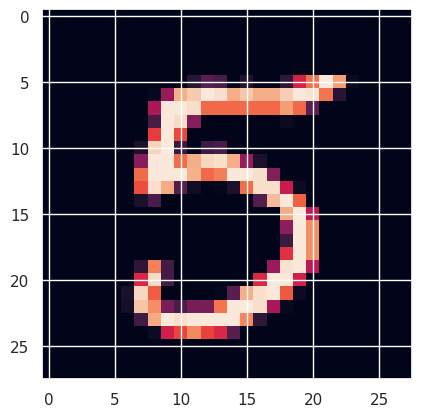

In [ ]:
plt.imshow(X_train[0].reshape(28, 28))

In [ ]:
y_train[0]

np.int64(5)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(n_estimators=20, verbose=True, random_state=42)
clf.fit(X_train, y_train)

      Iter       Train Loss   Remaining Time 
         1           1.9039            2.82m
         2           1.6729            2.54m
         3           1.5025            2.44m
         4           1.3616            2.32m
         5           1.2474            2.14m
         6           1.1497            2.02m
         7           1.0638            1.89m
         8           0.9901            1.73m
         9           0.9228            1.59m
        10           0.8635            1.45m
        20           0.5284            0.00s


GradientBoostingClassifier(n_estimators=20, random_state=42, verbose=True)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(n_estimators=40, verbose=True, random_state=42)
clf.fit(X_train, y_train)

      Iter       Train Loss   Remaining Time 
         1           1.9039            5.23m
         2           1.6729            5.36m
         3           1.5025            5.29m
         4           1.3616            5.07m
         5           1.2474            4.98m
         6           1.1497            4.86m
         7           1.0638            4.68m
         8           0.9901            4.55m
         9           0.9228            4.43m
        10           0.8635            4.27m
        20           0.5284            2.86m
        30           0.3780            1.44m
        40           0.2938            0.00s


GradientBoostingClassifier(n_estimators=40, random_state=42, verbose=True)

Для задачи классификации доступна опция использования метода `.staged_decision_function(X)`, возвращающего вероятности принадлежности объектов из выборки $X$ каждому из возможных классов согласно каждой из последовательно построенных версий алгоритма (т.е. что-то вроде сечения по $i$-му дереву).

Эта функция возвращает объект типа генератор. Преобразуем его к типу `np.array`

对于分类任务，可以使用 `.staged_decision_function(X)` 方法，该方法根据算法的每个顺序构建的版本（即沿着第 $i$ 棵树的切割）返回样本 $X$ 中对象属于每个可能类别的概率。

该函数返回一个生成器类型的对象。让我们将其转换为“np.array”类型

In [ ]:
import numpy as np

array_type_train = np.array(list(clf.staged_decision_function(X_train)))
array_type_test = np.array(list(clf.staged_decision_function(X_test)))

sdf1 = np.argmax(array_type_train, axis=-1)
sdf2 = np.argmax(array_type_test, axis=-1)
"""
sdf1 = np.argmax(np.array([stage for stage in clf.staged_decision_function(X_train)]), axis=-1)
sdf2 = np.argmax(np.array([stage for stage in clf.staged_decision_function(X_test )]), axis=-1)
"""

'\nsdf1 = np.argmax(np.array([stage for stage in clf.staged_decision_function(X_train)]), axis=-1)\nsdf2 = np.argmax(np.array([stage for stage in clf.staged_decision_function(X_test )]), axis=-1)\n'

In [ ]:
sdf1.shape

(40, 19999)

Посчитаем значение метрики качества на каждой итерации построения ансамблевого алгоритма и изобразим полученный график.

让我们计算构建集成算法的每次迭代中质量度量的值并显示结果图。

In [ ]:
from sklearn.metrics import accuracy_score

train_accuracy = [accuracy_score(sdf1[i], y_train) for i in range(40)]
test_accuracy = [accuracy_score(sdf2[i], y_test) for i in range(40)]

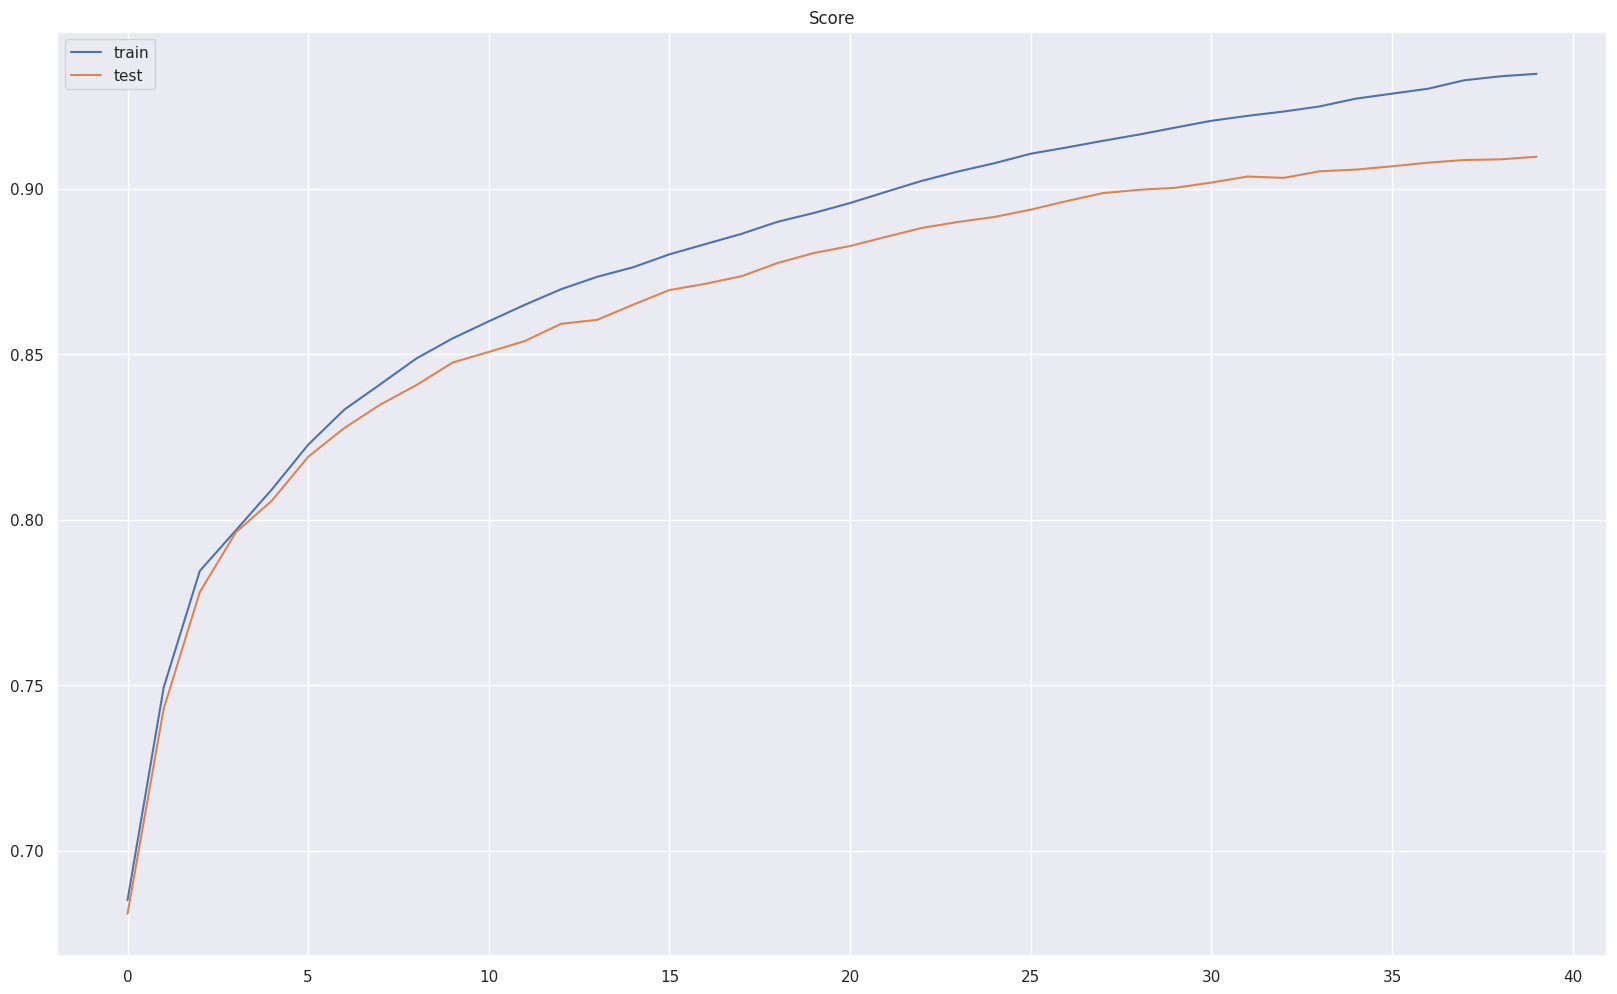

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize = (20,12))
plt.title('Score')

plt.plot(train_accuracy, label='train')
plt.plot(test_accuracy, label='test')

plt.legend()

Мы наблюдаем растущее отклонение графика качества на тренировочной выборке от качества на тестовой. Это наводит нас на мысль о возможном переобучении модели. Поговорим подробнее о переобучении.

我们观察到训练集质量图与测试集质量的偏差越来越大。这让我们思考模型可能存在的过度拟合问题。让我们更详细地谈论再培训。

## Переобучение

При помощи таких визуализаций можно отследить возникающий при переусложнении моделей эффект переобучения. Обнаружить его можно по расхождению графиков ошибки на тренировочной и тестовой выборках.

Для иллюстрации этого эффекта специально выберем маленькую тренировочную и большую тестовую выборки.

再培训

使用这样的可视化，可以追踪模型变得更加复杂时发生的过度拟合效应。它可以通过训练和测试样本上的误差图之间的差异来检测。

为了说明这种效果，我们将专门选择一个小型训练样本和一个大型测试样本。

In [ ]:
X = mnist_train.values[:, 1:]
y = mnist_train.values[:, 0]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8, shuffle=True, random_state=42
)
clf = GradientBoostingClassifier(n_estimators=50, max_depth=15, verbose=True)

clf.fit(X_train, y_train)

      Iter       Train Loss   Remaining Time 
         1           1.4771            7.18m
         2           1.1288           10.93m
         3           0.8994           10.07m
         4           0.7287            9.53m
         5           0.5974            9.20m
         6           0.4933            8.91m
         7           0.4095            8.64m
         8           0.3416            8.41m
         9           0.2838            8.17m
        10           0.2366            7.95m
        20           0.0391            5.89m
        30           0.0066            3.87m
        40           0.0011            1.92m
        50           0.0002            0.00s


GradientBoostingClassifier(max_depth=15, n_estimators=50, verbose=True)

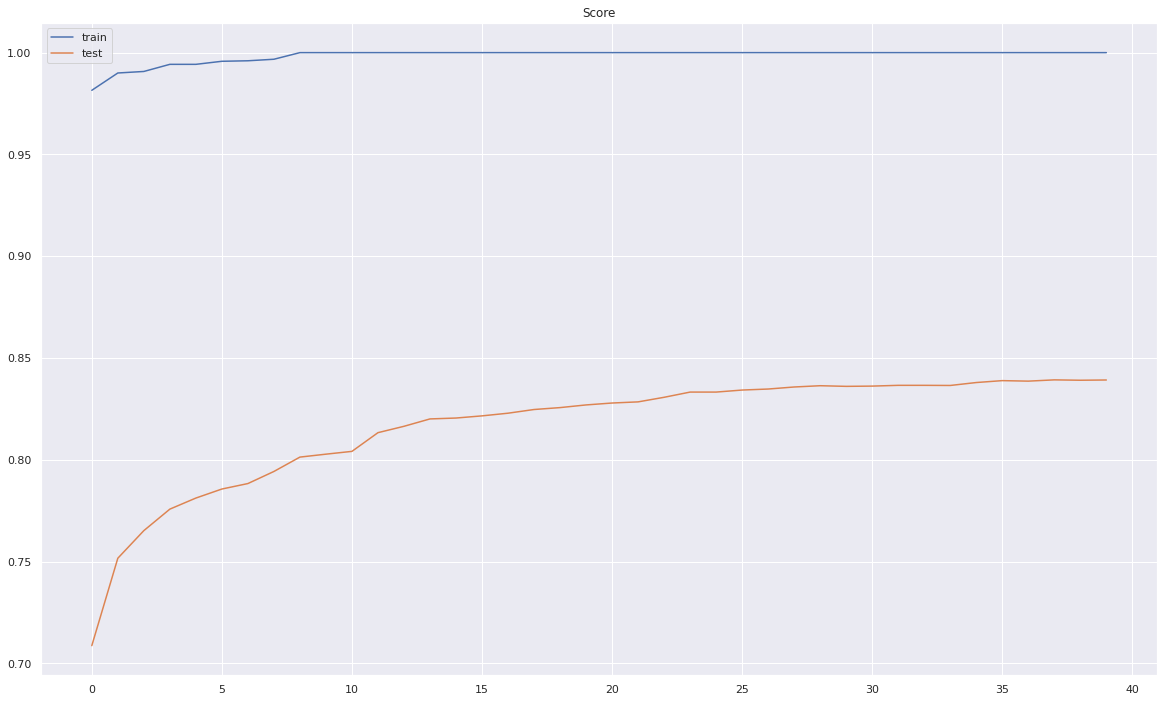

In [ ]:
array_type_train = np.array(list(clf.staged_decision_function(X_train)))
array_type_test = np.array(list(clf.staged_decision_function(X_test)))

sdf1 = np.argmax(array_type_train, axis=-1)
sdf2 = np.argmax(array_type_test, axis=-1)

train_accuracy = [accuracy_score(sdf1[i], y_train) for i in range(40)]
test_accuracy = [accuracy_score(sdf2[i], y_test) for i in range(40)]

plt.figure(figsize=(20, 12))
plt.title("Score")

plt.plot(train_accuracy, label="train")
plt.plot(test_accuracy, label="test")

plt.legend()

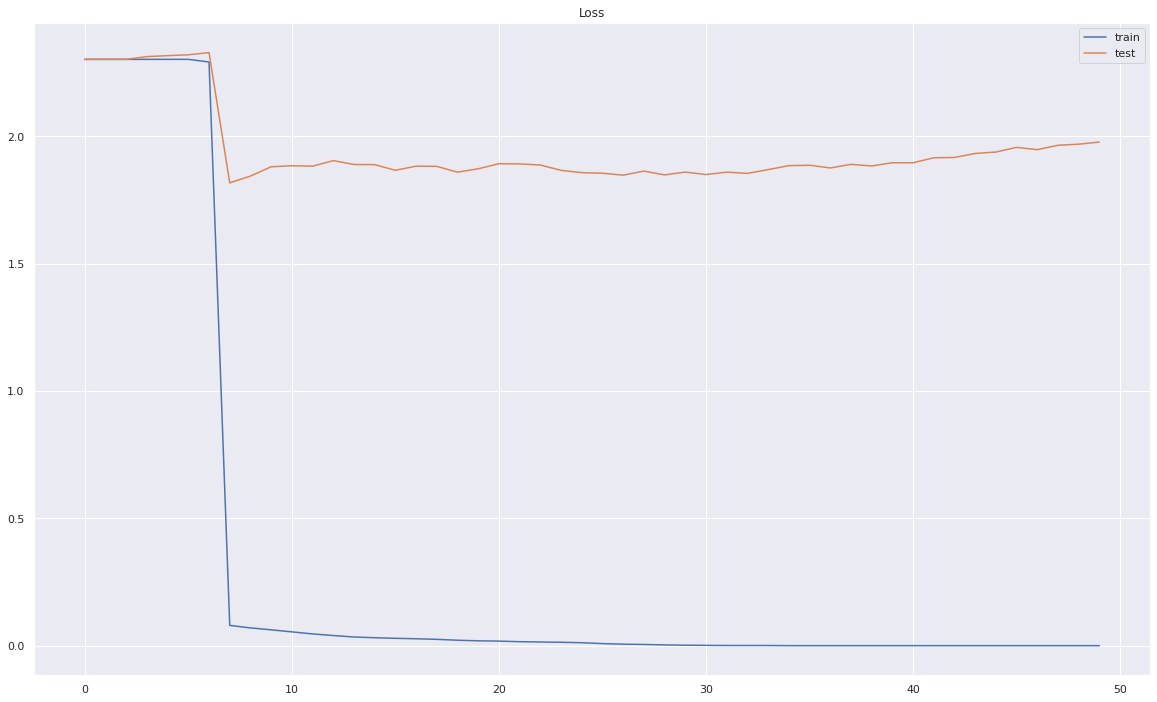

In [ ]:
from sklearn.metrics import log_loss

test_loss = [
    log_loss(y_test, array_type_test[i], labels=np.arange(10)) for i in range(len(sdf2))
]
train_loss = [
    log_loss(y_train, array_type_train[i], labels=np.arange(10))
    for i in range(len(sdf1))
]

plt.figure(figsize=(20, 12))
plt.title("Loss")

plt.plot(train_loss, label="train")
plt.plot(test_loss, label="test")

plt.legend()

В данном случае эффект переобучения очень явно выражен в резком расхождении графиков loss-функции на тренировочной и тестовой выборках. Таким образом, можно обнаружить оптимальное количество деревьев в ансамбле при фиксированных остальных гиперпараметрах.

在这种情况下，过度拟合的影响非常明显地体现在训练和测试样本上的损失函数图形之间的明显差异上。通过这种方式，可以在保持其他超参数固定的同时找到集成中树的最佳数量。